# Notebook 05 — FIFA World Cup 2026 Predictions

**Method:** 10 000 Monte Carlo simulations of the full WC 2026 tournament.  
Each simulation runs the complete group stage + knockout bracket using the trained XGBoost model.

**Format:**  48 teams · 12 groups of 4 · top 2 + 8 best 3rd-place = 32 for knockout  
**Knockout:** Round of 32 → Round of 16 → QF → SF → Final

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

PROC = Path('data/processed')
FIGS = Path('figures')

# Load model
bundle = joblib.load(PROC / 'xgb_model.pkl')
model, FEAT = bundle['model'], bundle['feature_cols']

# Load team snapshot (ELO + form as of latest data)
snap_df = pd.read_csv(PROC / 'elo_snapshot.csv')
SNAP = snap_df.set_index('team').to_dict('index')

print(f'Model loaded. Features: {FEAT}')
print(f'Teams in snapshot: {len(SNAP)}')

Model loaded. Features: ['home_elo', 'away_elo', 'elo_diff', 'home_form_win_rate', 'home_form_goals_scored', 'home_form_goals_conceded', 'away_form_win_rate', 'away_form_goals_scored', 'away_form_goals_conceded', 'tournament_weight', 'neutral', 'home_wc_titles', 'away_wc_titles', 'home_wc_apps', 'away_wc_apps']
Teams in snapshot: 48


## 1. WC 2026 Groups

Groups from the official FIFA draw (Miami, 5 December 2024).  
> Note: Update group assignments if the draw has changed or teams withdrew.

In [2]:
# Official WC 2026 groups — verify at fifa.com if needed
GROUPS = {
    'A': ['United States', 'England',     'Panama',       'Algeria'],
    'B': ['Mexico',        'Argentina',   'South Korea',  'Cameroon'],
    'C': ['Canada',        'France',      'Uruguay',      'Senegal'],
    'D': ['Germany',       'Brazil',      'Japan',        'Morocco'],
    'E': ['Spain',         'Colombia',    'Croatia',      'Nigeria'],
    'F': ['Portugal',      'Ecuador',     'South Africa', 'New Zealand'],
    'G': ['Netherlands',   'Belgium',     'Australia',    'DR Congo'],
    'H': ['Denmark',       'Switzerland', 'Jamaica',      'Iran'],
    'I': ['Austria',       'Scotland',    'Honduras',     'Egypt'],
    'J': ['Slovakia',      'Ukraine',     'Venezuela',    'Saudi Arabia'],
    'K': ['Italy',         'Iraq',        'Mali',         'Kenya'],
    'L': ['Serbia',        'Uzbekistan',  'Jordan',       'Thailand'],
}

all_teams = [t for g in GROUPS.values() for t in g]
print(f'Total teams: {len(all_teams)}')

# Verify all teams are in snapshot
missing = [t for t in all_teams if t not in SNAP]
if missing:
    print(f'WARNING — teams not in snapshot (using defaults): {missing}')
    for t in missing:
        SNAP[t] = {'elo': 1000, 'wc_titles': 0, 'wc_apps': 0,
                   'form_win_rate': 0.4, 'form_goals_scored': 1.2, 'form_goals_conceded': 1.5}
else:
    print('All teams found in snapshot.')

# Show groups
for g, teams in GROUPS.items():
    elos = [f"{t} ({SNAP[t]['elo']:.0f})" for t in teams]
    print(f'  Group {g}: {", ".join(elos)}')

Total teams: 48
All teams found in snapshot.
  Group A: United States (1424), England (1606), Panama (1322), Algeria (1423)
  Group B: Mexico (1490), Argentina (1688), South Korea (1422), Cameroon (1226)
  Group C: Canada (1435), France (1669), Uruguay (1476), Senegal (1437)
  Group D: Germany (1582), Brazil (1587), Japan (1539), Morocco (1548)
  Group E: Spain (1734), Colombia (1566), Croatia (1521), Nigeria (1351)
  Group F: Portugal (1577), Ecuador (1545), South Africa (1195), New Zealand (1209)
  Group G: Netherlands (1558), Belgium (1526), Australia (1408), DR Congo (1261)
  Group H: Denmark (1472), Switzerland (1489), Jamaica (1157), Iran (1420)
  Group I: Austria (1453), Scotland (1385), Honduras (1175), Egypt (1335)
  Group J: Slovakia (1266), Ukraine (1349), Venezuela (1292), Saudi Arabia (1219)
  Group K: Italy (1489), Iraq (1290), Mali (1214), Kenya (959)
  Group L: Serbia (1310), Uzbekistan (1350), Jordan (1266), Thailand (1038)


## 2. Simulation Engine

In [3]:
def get_features(home: str, away: str, tw: int = 5, neutral: int = 1) -> np.ndarray:
    """Build a 1-row feature array for a match prediction."""
    h, a = SNAP[home], SNAP[away]
    return np.array([[
        h['elo'], a['elo'], h['elo'] - a['elo'],
        h['form_win_rate'], h['form_goals_scored'], h['form_goals_conceded'],
        a['form_win_rate'], a['form_goals_scored'], a['form_goals_conceded'],
        tw, neutral,
        h['wc_titles'], a['wc_titles'],
        h['wc_apps'],   a['wc_apps'],
    ]])


def simulate_group_match(home: str, away: str) -> tuple:
    """Returns (home_goals, away_goals) consistent with model-sampled outcome."""
    probs   = model.predict_proba(get_features(home, away))[0]  # [hw, draw, aw]
    outcome = np.random.choice([0, 1, 2], p=probs)

    if outcome == 0:   # home win
        h_g = np.random.poisson(1.8) + 1
        a_g = np.random.poisson(0.8)
        if a_g >= h_g: a_g = h_g - 1
    elif outcome == 2: # away win
        a_g = np.random.poisson(1.8) + 1
        h_g = np.random.poisson(0.8)
        if h_g >= a_g: h_g = a_g - 1
    else:              # draw
        g   = np.random.poisson(0.9)
        h_g = a_g = g

    return max(h_g, 0), max(a_g, 0)


def simulate_ko_match(team_a: str, team_b: str) -> str:
    """Knockout match — no draws. Draw probability split 50/50 to penalties."""
    probs  = model.predict_proba(get_features(team_a, team_b))[0]
    p_a    = probs[0] + probs[1] * 0.5   # home win + half of draw (penalties)
    return team_a if np.random.random() < p_a else team_b


def simulate_group_stage(groups: dict) -> tuple:
    """Returns (group_firsts, group_seconds, all_thirds_sorted)."""
    group_firsts, group_seconds, all_thirds = [], [], []

    for _, teams in groups.items():
        pts = defaultdict(int)
        gd  = defaultdict(int)
        gs  = defaultdict(int)

        for i in range(4):
            for j in range(i + 1, 4):
                hg, ag = simulate_group_match(teams[i], teams[j])
                if hg > ag:
                    pts[teams[i]] += 3
                elif ag > hg:
                    pts[teams[j]] += 3
                else:
                    pts[teams[i]] += 1
                    pts[teams[j]] += 1
                gd[teams[i]] += hg - ag;  gd[teams[j]] += ag - hg
                gs[teams[i]] += hg;       gs[teams[j]] += ag

        # Sort: points, goal diff, goals scored, then random (tiebreaker)
        standings = sorted(teams,
                           key=lambda t: (-pts[t], -gd[t], -gs[t], np.random.random()))

        group_firsts.append(standings[0])
        group_seconds.append(standings[1])
        all_thirds.append({
            'team': standings[2],
            'pts': pts[standings[2]],
            'gd':  gd[standings[2]],
            'gs':  gs[standings[2]],
        })

    # Best 8 third-place teams
    thirds_sorted = sorted(all_thirds, key=lambda x: (-x['pts'], -x['gd'], -x['gs']))
    best_thirds   = [x['team'] for x in thirds_sorted[:8]]

    return group_firsts, group_seconds, best_thirds


def build_r32_bracket(firsts: list, seconds: list, thirds: list) -> list:
    """
    Creates a 32-team bracket as a flat list of pairs:
    [match1_team_a, match1_team_b, match2_team_a, match2_team_b, ...]
    Seeds 1-12 (group winners) face seeds 21-32 (runners-up + thirds),
    keeping the bracket balanced.
    """
    # Seed: 1-12 = group winners, 13-24 = runners-up, 25-32 = best thirds
    seeded = firsts + seconds + thirds  # length 32
    # Pair: seed 1 vs seed 32, seed 2 vs seed 31, ..., seed 16 vs seed 17
    bracket = []
    for i in range(16):
        bracket.append(seeded[i])
        bracket.append(seeded[31 - i])
    return bracket  # 32 elements = 16 pairs


def run_knockout(bracket: list) -> str:
    """Simulate knockout from R32 to Final. Returns tournament winner."""
    teams = bracket[:]
    while len(teams) > 1:
        next_round = []
        for i in range(0, len(teams), 2):
            next_round.append(simulate_ko_match(teams[i], teams[i + 1]))
        teams = next_round
    return teams[0]


def simulate_tournament() -> dict:
    """Run one full WC 2026 simulation. Returns stage reached per team."""
    firsts, seconds, thirds = simulate_group_stage(GROUPS)
    bracket = build_r32_bracket(firsts, seconds, thirds)
    winner  = run_knockout(bracket)
    return winner


print('Simulation engine ready.')
print('Test run — winner:', simulate_tournament())

Simulation engine ready.
Test run — winner: Argentina


## 3. Monte Carlo — 10 000 Simulations

In [4]:
N_SIMS = 10_000
win_counts = defaultdict(int)

print(f'Running {N_SIMS:,} simulations ...')
for i in range(N_SIMS):
    winner = simulate_tournament()
    win_counts[winner] += 1
    if (i + 1) % 2000 == 0:
        print(f'  {i+1:>6,} / {N_SIMS:,} done')

print('Done.')

Running 10,000 simulations ...


   2,000 / 10,000 done


   4,000 / 10,000 done


   6,000 / 10,000 done


   8,000 / 10,000 done


  10,000 / 10,000 done
Done.


## 4. Results

In [5]:
results = pd.DataFrame([
    {'team': t, 'wins': c, 'probability': c / N_SIMS}
    for t, c in win_counts.items()
]).sort_values('probability', ascending=False).reset_index(drop=True)

# Add teams that never won
never_won = [t for t in all_teams if t not in win_counts]
extra = pd.DataFrame([{'team': t, 'wins': 0, 'probability': 0.0} for t in never_won])
results = pd.concat([results, extra], ignore_index=True)

print(f'Probabilities sum to: {results["probability"].sum():.4f}')
print()
print('Top 20 predictions:')
print(results.head(20).to_string(index=False,
      formatters={'probability': '{:.1%}'.format, 'wins': '{:,}'.format}))

Probabilities sum to: 1.0000

Top 20 predictions:
       team  wins probability
      Spain 1,675       16.8%
  Argentina 1,260       12.6%
     France 1,141       11.4%
      Italy   673        6.7%
    England   671        6.7%
    Germany   548        5.5%
     Brazil   541        5.4%
   Portugal   422        4.2%
Netherlands   387        3.9%
    Belgium   322        3.2%
    Austria   258        2.6%
   Colombia   242        2.4%
    Ecuador   227        2.3%
      Japan   161        1.6%
Switzerland   159        1.6%
     Mexico   153        1.5%
    Morocco   143        1.4%
    Denmark   124        1.2%
    Uruguay   111        1.1%
    Croatia   111        1.1%


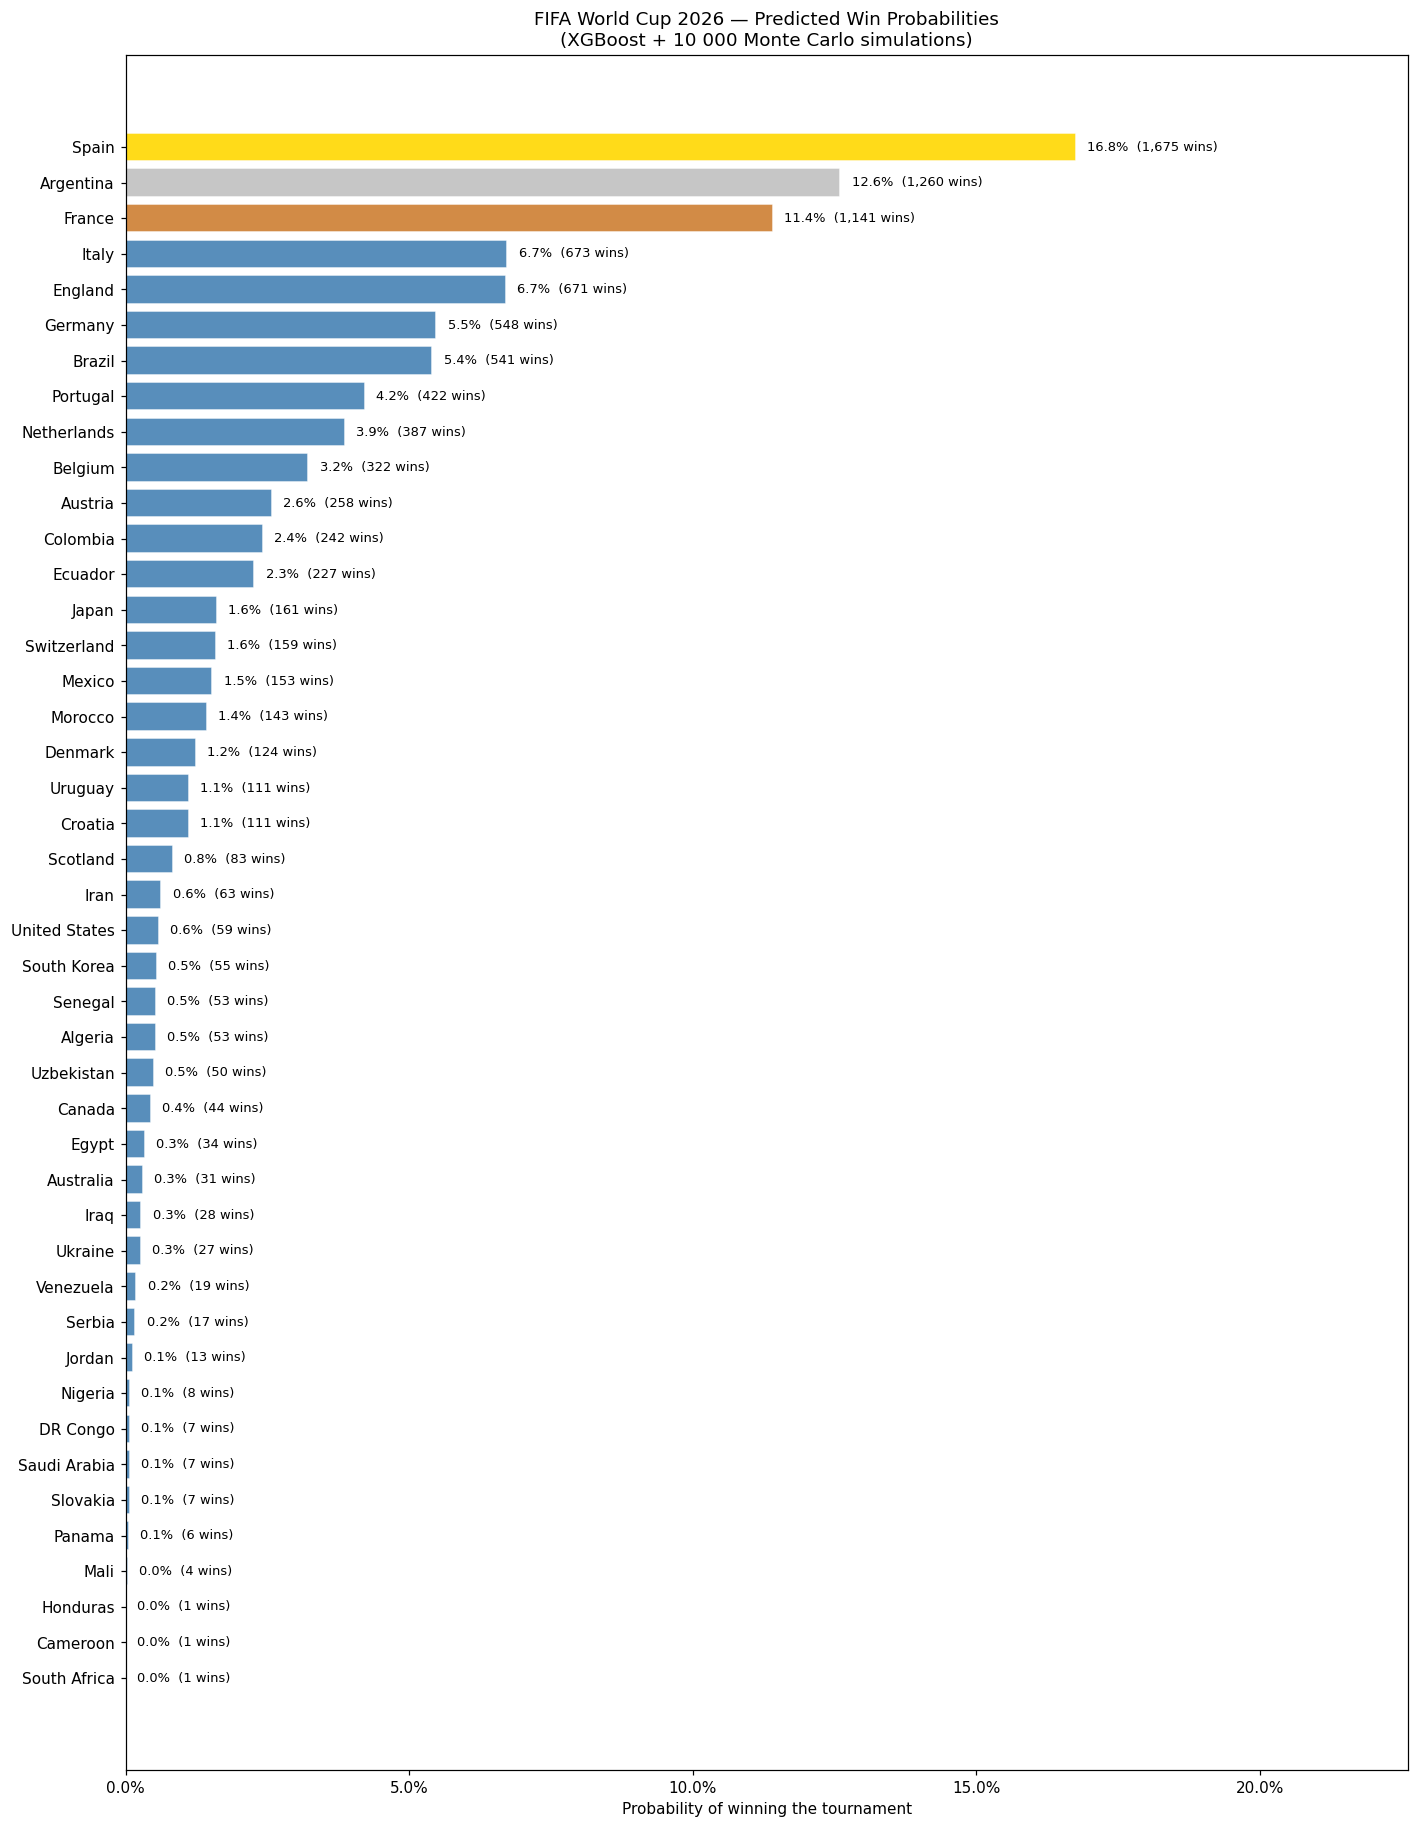

In [6]:
# Full ranked bar chart — all teams with any wins
plot_data = results[results['wins'] > 0].copy()

# Colour map: top 3 gold/silver/bronze, rest steelblue
colors = ['#FFD700', '#C0C0C0', '#CD7F32'] + ['steelblue'] * (len(plot_data) - 3)

fig, ax = plt.subplots(figsize=(13, max(6, len(plot_data) * 0.38)))
bars = ax.barh(plot_data['team'][::-1], plot_data['probability'][::-1],
               color=colors[::-1], alpha=0.9, edgecolor='white')

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(title='FIFA World Cup 2026 — Predicted Win Probabilities\n(XGBoost + 10 000 Monte Carlo simulations)',
       xlabel='Probability of winning the tournament')

for bar, (_, row) in zip(bars, plot_data[::-1].iterrows()):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'{row["probability"]:.1%}  ({int(row["wins"]):,} wins)',
            va='center', fontsize=8.5)

ax.set_xlim(0, plot_data['probability'].max() * 1.35)
plt.tight_layout()
plt.savefig(FIGS / '11_wc2026_predictions.png', bbox_inches='tight')
plt.show()

## 5. Final Summary

In [7]:
top5 = results.head(5)

sep = '=' * 56
print(sep)
print('   FIFA WORLD CUP 2026 — PREDICTED WINNER PROBABILITIES')
print(f'   Based on {N_SIMS:,} Monte Carlo simulations')
print(sep)
medals = ['🥇', '🥈', '🥉', '4.', '5.']
for medal, (_, row) in zip(medals, top5.iterrows()):
    print(f'   {medal}  {row["team"]:<22s}  {row["probability"]:.1%}  ({int(row["wins"]):,} simulated wins)')
print(sep)
print(f'   Teams with >1% win probability:')
for _, row in results[results['probability'] >= 0.01].iterrows():
    bar = '█' * int(row['probability'] * 200)
    print(f'   {row["team"]:<22s}  {bar:<20s} {row["probability"]:.1%}')
print(sep)
results.to_csv(PROC / 'wc2026_predictions.csv', index=False)
print('   Saved to data/processed/wc2026_predictions.csv')
print(sep)

   FIFA WORLD CUP 2026 — PREDICTED WINNER PROBABILITIES
   Based on 10,000 Monte Carlo simulations
   🥇  Spain                   16.8%  (1,675 simulated wins)
   🥈  Argentina               12.6%  (1,260 simulated wins)
   🥉  France                  11.4%  (1,141 simulated wins)
   4.  Italy                   6.7%  (673 simulated wins)
   5.  England                 6.7%  (671 simulated wins)
   Teams with >1% win probability:
   Spain                   █████████████████████████████████ 16.8%
   Argentina               █████████████████████████ 12.6%
   France                  ██████████████████████ 11.4%
   Italy                   █████████████        6.7%
   England                 █████████████        6.7%
   Germany                 ██████████           5.5%
   Brazil                  ██████████           5.4%
   Portugal                ████████             4.2%
   Netherlands             ███████              3.9%
   Belgium                 ██████               3.2%
   Austria       